In [4]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import scipy.io as sio
import pyproj
from scipy.interpolate import RegularGridInterpolator
from scipy import stats
from sklearn.decomposition import PCA

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams['figure.dpi'] = 110

MATHIEU    = Path.home()/'Downloads'/'Mathieu'/'Data'
BEDMACHINE = Path.home()/'DataFiles'/'BedMachineAntarctica-v3.nc'
ERA5_T2M   = Path.home()/'DataFiles'/'ae3baa6a74f0aa315dc3de6f83298f0e.nc'
BROMWICH   = MATHIEU/'recon_t2m_1958-2022_ano.final.nc'
ICECORES   = MATHIEU/'Age_d18O_WNanddiffNullHyp.mat'
AWSMAT     = MATHIEU/'dataAWS.mat'
PALEO_LDC  = MATHIEU/'dataPALEO_LDC.mat'

REGION_NAMES = {1:'East Antarctic Plateau', 2:'Wilkes Land Coast',
                3:'Weddell Sea Coast', 4:'Antarctic Peninsula', 5:'WAIS',
                6:'Victoria Land / Ross Sea', 7:'Dronning Maud Land Coast'}
REGION_RGB = {1:(29,143,255), 2:(0,255,255), 3:(143,237,143), 4:(255,214,0),
              5:(255,164,0), 6:(255,0,0), 7:(204,132,62)}

YEAR_START, YEAR_STOP, TREND_LIM = 1980, 2020, 0.65
CORE_START, CORE_STOP = 1950, 2020
LEV = np.arange(-0.65, 0.66, 0.1)     # discrete bands used by the published figure

for p in (BEDMACHINE, ERA5_T2M, BROMWICH, ICECORES, AWSMAT):
    print('OK      ' if p.exists() else 'MISSING ', p)


OK       /Users/advik/DataFiles/BedMachineAntarctica-v3.nc
OK       /Users/advik/DataFiles/ae3baa6a74f0aa315dc3de6f83298f0e.nc
OK       /Users/advik/Downloads/Mathieu/Data/recon_t2m_1958-2022_ano.final.nc
OK       /Users/advik/Downloads/Mathieu/Data/Age_d18O_WNanddiffNullHyp.mat
OK       /Users/advik/Downloads/Mathieu/Data/dataAWS.mat


In [27]:
%pip install cmocean


SOUTH_POLAR = ccrs.SouthPolarStereo(central_longitude=0.0)
PLATE = ccrs.PlateCarree()

def polar_axes(fig, rect=111, lat_max=-62.0, labels=True):
    args = rect if isinstance(rect, tuple) else (rect,)
    ax = fig.add_subplot(*args, projection=SOUTH_POLAR)
    ax.set_extent([-180, 180, -90, lat_max], crs=PLATE)
    th = np.linspace(0, 2*np.pi, 200)
    ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*0.5 + 0.5),
                    transform=ax.transAxes)
    gl = ax.gridlines(draw_labels=labels, linewidth=.4, color='0.6', alpha=.7)
    gl.n_steps = 90
    return ax

def add_coast(ax, lw=1.5, color='k'):
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=lw, edgecolor=color)
    return ax

def surfm(ax, lat, lon, z, **kw):
    kw.setdefault('shading', 'auto'); kw.setdefault('transform', PLATE)
    return ax.pcolormesh(lon, lat, z, **kw)

def scatterm(ax, lat, lon, s=150, c=None, **kw):
    kw.setdefault('transform', PLATE); kw.setdefault('zorder', 5)
    return ax.scatter(lon, lat, s=s, c=c, **kw)

import cmocean

def cmocean_like(name, n):
    """Real cmocean tables. '-name' means reversed, as in MATLAB's cmocean('-algae',7)."""
    cm = getattr(cmocean.cm, name.lstrip('-'))
    if name.startswith('-'):
        cm = cm.reversed()
    return cm.resampled(n)


def region_cmap():
    cm = ListedColormap([np.array(REGION_RGB[i])/255 for i in range(1, 8)])
    return cm, BoundaryNorm(np.arange(.5, 8.5, 1.), cm.N)

def region_legend(ax, **kw):
    h = [Patch(facecolor=np.array(REGION_RGB[i])/255, edgecolor='k', lw=.4,
               label=f'{i} {REGION_NAMES[i]}') for i in range(1, 8)]
    kw.setdefault('loc', 'center left'); kw.setdefault('bbox_to_anchor', (1.02, .5))
    kw.setdefault('frameon', False)
    return ax.legend(handles=h, **kw)

print('map helpers defined')


  Using cached cmocean-4.0.3-py3-none-any.whl.metadata (4.2 kB)
Using cached cmocean-4.0.3-py3-none-any.whl (421 kB)
Note: you may need to restart the kernel to use updated packages.
map helpers defined


In [3]:
class SurfaceElevation:
    def __init__(self, x, y, z, proj, name, mask=None):
        self.x, self.y, self.z, self.proj, self.name = x, y, z, proj, name
        self._i = RegularGridInterpolator((y, x), z, method='linear',
                                          bounds_error=False, fill_value=np.nan)
        self._m = None
        if mask is not None:
            self._m = RegularGridInterpolator((y, x), mask.astype('float32'),
                        method='nearest', bounds_error=False, fill_value=np.nan)

    def _pts(self, lat, lon):
        lat = np.asarray(lat, float); lon = np.asarray(lon, float)
        gx, gy = self.proj(((lon + 180) % 360) - 180, lat)
        return np.stack([np.ravel(gy), np.ravel(gx)], -1), np.shape(lat)

    def __call__(self, lat, lon):
        p, sh = self._pts(lat, lon); return self._i(p).reshape(sh)


In [5]:
SOUTH_POLAR = ccrs.SouthPolarStereo(central_longitude=0.0)
PLATE = ccrs.PlateCarree()

def polar_axes(fig, rect=111, lat_max=-62.0, labels=True):
    """Equivalent of worldmap([-90 lat_max], [0 360])."""
    args = rect if isinstance(rect, tuple) else (rect,)
    ax = fig.add_subplot(*args, projection=SOUTH_POLAR)
    ax.set_extent([-180, 180, -90, lat_max], crs=PLATE)
    th = np.linspace(0, 2*np.pi, 200)
    ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*0.5 + 0.5),
                    transform=ax.transAxes)
    gl = ax.gridlines(draw_labels=labels, linewidth=.4, color='0.6', alpha=.7)
    gl.n_steps = 90
    return ax

def add_coast(ax, lw=1.5, color='k'):
    """Natural Earth coastline. bedmap2's separate grounding line has no
    Natural Earth equivalent, so only the coast is drawn."""
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=lw, edgecolor=color)
    return ax

def surfm(ax, lat, lon, z, **kw):
    kw.setdefault('shading', 'auto'); kw.setdefault('transform', PLATE)
    return ax.pcolormesh(lon, lat, z, **kw)

def scatterm(ax, lat, lon, s=150, c=None, **kw):
    kw.setdefault('transform', PLATE); kw.setdefault('zorder', 5)
    return ax.scatter(lon, lat, s=s, c=c, **kw)

# Stand-ins for cmocean. Perceptual approximations, not the exact lookup
# tables -- `pip install cmocean` and swap these if you need the real ones.
_CMO = {'balance': ['#181c43','#2a68a8','#8bbcd9','#f4f4f4','#e59b74','#b3341f','#3e0a12'],
        'algae':   ['#d7f2c0','#93d08a','#4fa963','#1c7f4d','#125437','#0b2c1e'],
        'rain':    ['#e8e2d8','#9fc9b0','#54a9a6','#3a72a0','#3f3f8f','#3b1a4d']}

def cmocean_like(name, n):
    cols = _CMO[name.lstrip('-')]
    if name.startswith('-'): cols = cols[::-1]
    return LinearSegmentedColormap.from_list(f'cmo_{name}', cols, N=n)

def region_cmap():
    cm = ListedColormap([np.array(REGION_RGB[i])/255 for i in range(1, 8)])
    return cm, BoundaryNorm(np.arange(.5, 8.5, 1.), cm.N)

def region_legend(ax, **kw):
    h = [Patch(facecolor=np.array(REGION_RGB[i])/255, edgecolor='k', lw=.4,
               label=f'{i} {REGION_NAMES[i]}') for i in range(1, 8)]
    kw.setdefault('loc', 'center left'); kw.setdefault('bbox_to_anchor', (1.02, .5))
    kw.setdefault('frameon', False)
    return ax.legend(handles=h, **kw)

cmap_t = cmocean_like('balance', 13)
print('map helpers defined')


map helpers defined


In [6]:
class SurfaceElevation:
    """Callable surface-elevation field, replacing bedmap2_interp(...,'surface')."""
    def __init__(self, x, y, z, proj, name, mask=None):
        self.x, self.y, self.z, self.proj, self.name = x, y, z, proj, name
        self._i = RegularGridInterpolator((y, x), z, method='linear',
                                          bounds_error=False, fill_value=np.nan)
        self._m = None
        if mask is not None:
            self._m = RegularGridInterpolator((y, x), mask.astype('float32'),
                        method='nearest', bounds_error=False, fill_value=np.nan)

    def _pts(self, lat, lon):
        lat = np.asarray(lat, float); lon = np.asarray(lon, float)
        gx, gy = self.proj(((lon + 180) % 360) - 180, lat)   # accepts 0-360 or -180..180
        return np.stack([np.ravel(gy), np.ravel(gx)], -1), np.shape(lat)

    def __call__(self, lat, lon):
        p, sh = self._pts(lat, lon)
        return self._i(p).reshape(sh)

    def land_mask(self, lat, lon, include_shelves=True):
        """BedMachine mask: 0 ocean, 1 ice-free land, 2 grounded ice,
        3 floating ice, 4 Lake Vostok."""
        if self._m is None:
            return self(lat, lon) > 10.
        p, sh = self._pts(lat, lon)
        m = np.nan_to_num(self._m(p).reshape(sh), nan=0).astype(int)
        keep = (1, 2, 4) + ((3,) if include_shelves else ())
        return np.isin(m, keep)

def load_bedmachine(path=BEDMACHINE, stride=2):
    """BedMachine Antarctica v3, EPSG:3031. stride=2 -> 1 km, ~178 MB."""
    ds = xr.open_dataset(path); s = slice(None, None, stride)
    z  = ds['surface'][s, s].values.astype('float32')
    mk = ds['mask'][s, s].values
    x  = ds['x'][s].values.astype(float)
    y  = ds['y'][s].values.astype(float)
    ds.close()
    if x[0] > x[-1]: x, z, mk = x[::-1], z[:, ::-1], mk[:, ::-1]
    if y[0] > y[-1]: y, z, mk = y[::-1], z[::-1, :], mk[::-1, :]
    return SurfaceElevation(x, y, z, pyproj.Proj('EPSG:3031'),
                            f'BedMachine v3 surface ({500*stride} m)', mk)

elev = load_bedmachine()
print(elev.name, elev.z.shape)

known = {'South Pole':(-89.99,0.,2835), 'Dome C':(-75.10,123.35,3233),
         'WAIS Divide':(-79.47,-112.09,1766), 'Vostok':(-78.47,106.84,3488),
         'Dome A':(-80.37,77.37,4093), 'Byrd':(-80.01,-119.32,1530),
         'Talos Dome':(-72.78,159.07,2315), 'Law Dome':(-66.77,112.81,1370)}
pd.DataFrame([{'site':k, 'interp_m':round(float(elev(la,lo)),1), 'ref_m':r,
               'diff_m':round(float(elev(la,lo))-r,1)}
              for k,(la,lo,r) in known.items()]).set_index('site')


BedMachine v3 surface (1000 m) (6667, 6667)


,interp_m,ref_m,diff_m
site,,,
South Pole,2827.1,2835,-7.9
Dome C,3239.2,3233,6.2
WAIS Divide,1781.0,1766,15.0
Vostok,3462.5,3488,-25.5
Dome A,4049.4,4093,-43.6
Byrd,1529.6,1530,-0.4
Talos Dome,2351.9,2315,36.9
Law Dome,1355.3,1370,-14.7


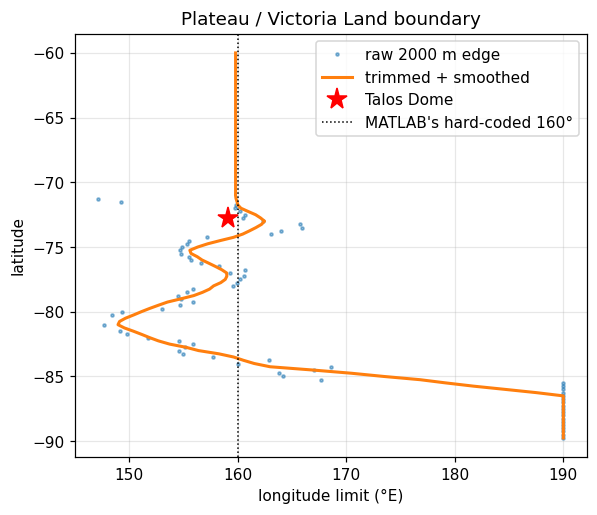

northern extrapolated value: 159.80°E


In [7]:
LON_MIN, LON_MAX = 145., 190.
PLATEAU_ALTI, TAPER_MARGIN, MIN_DROP_DEG = 2000., 200., 2.0
LAT_STEP, LON_STEP, SMOOTH_WINDOW = .25, .05, 9

def plateau_edge_longitude(elev, lat):
    """East edge of the *contiguous* 2000 m surface, scanning east from 145E.

    Inside 145-190E the plateau rule in regions_Ant2K carries no elevation test
    of its own, so this table IS the 2000 m contour there. Taking the first
    sustained drop (not the last high sample) discards detached Transantarctic
    peaks -- the "high mountains we want to exclude" of the source comment.
    """
    lons = np.arange(LON_MIN, LON_MAX + LON_STEP, LON_STEP)
    z = np.nan_to_num(elev(np.full_like(lons, lat), lons), nan=0.)
    high = z >= PLATEAU_ALTI
    if not high.any() or z.max() < PLATEAU_ALTI + TAPER_MARGIN:
        return np.nan                       # no plateau, or too close to call
    fh = int(np.flatnonzero(high)[0])
    run = max(1, int(round(MIN_DROP_DEG / LON_STEP)))
    low = ~high[fh:]
    if not low.any():
        return LON_MAX                      # plateau spans the band (near pole)
    idx = np.flatnonzero(np.convolve(low.astype(int), np.ones(run, int), 'valid') == run)
    return LON_MAX if idx.size == 0 else float(lons[fh + int(idx[0])])

def trim_north_taper(v, drop_deg=6., window=5):
    """Drop the collapsing northern tail where the plateau fragments (~71S)."""
    v = v.copy()
    while True:
        ok = np.flatnonzero(np.isfinite(v))
        if ok.size <= window: break
        if v[ok[-1]] < np.median(v[ok[-(window+1):-1]]) - drop_deg:
            v[ok[-1]] = np.nan
        else:
            break
    return v

def fill_north(v):
    v = v.copy(); ok = np.flatnonzero(np.isfinite(v))
    v[:ok[0]] = v[ok[0]]; v[ok[-1]+1:] = v[ok[-1]]
    i = np.arange(len(v))
    return np.interp(i, i[np.isfinite(v)], v[np.isfinite(v)])

def smooth(v, w):
    return np.convolve(np.pad(v, w//2, mode='edge'), np.ones(w)/w, 'valid')

lats_v = np.arange(-89.75, -59.99, LAT_STEP)
raw  = np.array([plateau_edge_longitude(elev, la) for la in lats_v])
vlim = np.clip(smooth(fill_north(trim_north_taper(raw)), SMOOTH_WINDOW), LON_MIN, LON_MAX)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(raw, lats_v, '.', ms=4, alpha=.5, label='raw 2000 m edge')
ax.plot(vlim, lats_v, '-', lw=2, label='trimmed + smoothed')
ax.plot(159.07, -72.78, 'r*', ms=14, label='Talos Dome')
ax.axvline(160, color='k', ls=':', lw=1, label="MATLAB's hard-coded 160°")
ax.set_xlabel('longitude limit (°E)'); ax.set_ylabel('latitude')
ax.set_title('Plateau / Victoria Land boundary'); ax.legend(); ax.grid(alpha=.3)
plt.show()

print(f'northern extrapolated value: {vlim[-1]:.2f}°E')


In [8]:
PENI, WED, B_AI = -74., 330., 67.

def regions_ant2k(lat, lon, elevi, edml_zero=True):
    """Port of regions_Ant2K.m. Rules applied in order, later ones overriding.

    edml_zero=True reproduces a defect: MATLAB lines 47-50 assign 0 -- not a
    region in 1..7 -- to the plateau where lon<30 or lon>=300, and nothing
    later overwrites it because every subsequent DML/Weddell rule requires
    elev<2000. caxis([1 7]) clamps 0 to the plateau colour, hiding it.
    Pass False for what was almost certainly meant.
    """
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    elevi = np.asarray(elevi, float); sh = lat.shape
    vlat = lat.ravel(); vlon = np.mod(lon.ravel(), 360.); ve = elevi.ravel()
    reg = np.full(vlat.shape, np.nan)
    vll = np.interp(vlat, lats_v, vlim, left=np.nan, right=np.nan)  # MATLAB interp1

    with np.errstate(invalid='ignore'):
        # Plateau
        reg[(vlon < 145) & (ve > PLATEAU_ALTI)] = 1
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlon < vll)] = 1
        reg[(vlon >= 145) & (vlon < 350) & (vlat < -84) & (ve >= 0)] = 1
        # EDML carve-out (the 0 bug)
        f = 0. if edml_zero else 1.
        reg[(vlon < 30) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon >= 300) & (ve > PLATEAU_ALTI)] = f
        # Dronning Maud Land coast
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat > -76) & (ve >= 0)] = 7
        reg[(vlon > 0) & (vlon < B_AI) & (ve < PLATEAU_ALTI)] = 7
        # Weddell Sea coast
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat < -75) & (ve >= 0)] = 3
        reg[(vlon >= 300) & (vlon < WED) & (ve < PLATEAU_ALTI)] = 3
        # Indian Ocean sector (Wilkes Land coast)
        reg[(vlon >= B_AI) & (vlon < 145) & (ve < PLATEAU_ALTI)] = 2
        reg[(vlon >= 145) & (vlon < 160) & (ve >= 0) & (vlon < vll)
            & (ve < PLATEAU_ALTI) & (vlat > -72)] = 2
        # Victoria Land
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlat < -74) & (vlon > vll)] = 6
        reg[(vlon >= 160) & (vlon < 190) & (ve >= 0) & (vlon > vll)] = 6
        # WAIS
        reg[(vlon >= 190) & (vlon < 280) & (vlat > -85) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 300) & (vlat > -85) & (vlat < PENI+.5) & (ve >= 0)] = 5
        # Peninsula
        reg[(vlon >= 280) & (vlon < 305) & (vlat > PENI) & (ve >= 0)] = 4
    return reg.reshape(sh)

lat_g = np.arange(-90., -59.95, .1)
lon_g = np.arange(0., 360.05, .1)
LA, LO = np.meshgrid(lat_g, lon_g, indexing='ij')
Z = elev(LA, LO)
ri_raw = regions_ant2k(LA, LO, Z, edml_zero=True)
ri_fix = regions_ant2k(LA, LO, Z, edml_zero=False)
print('grid', LA.shape)


grid (301, 3601)


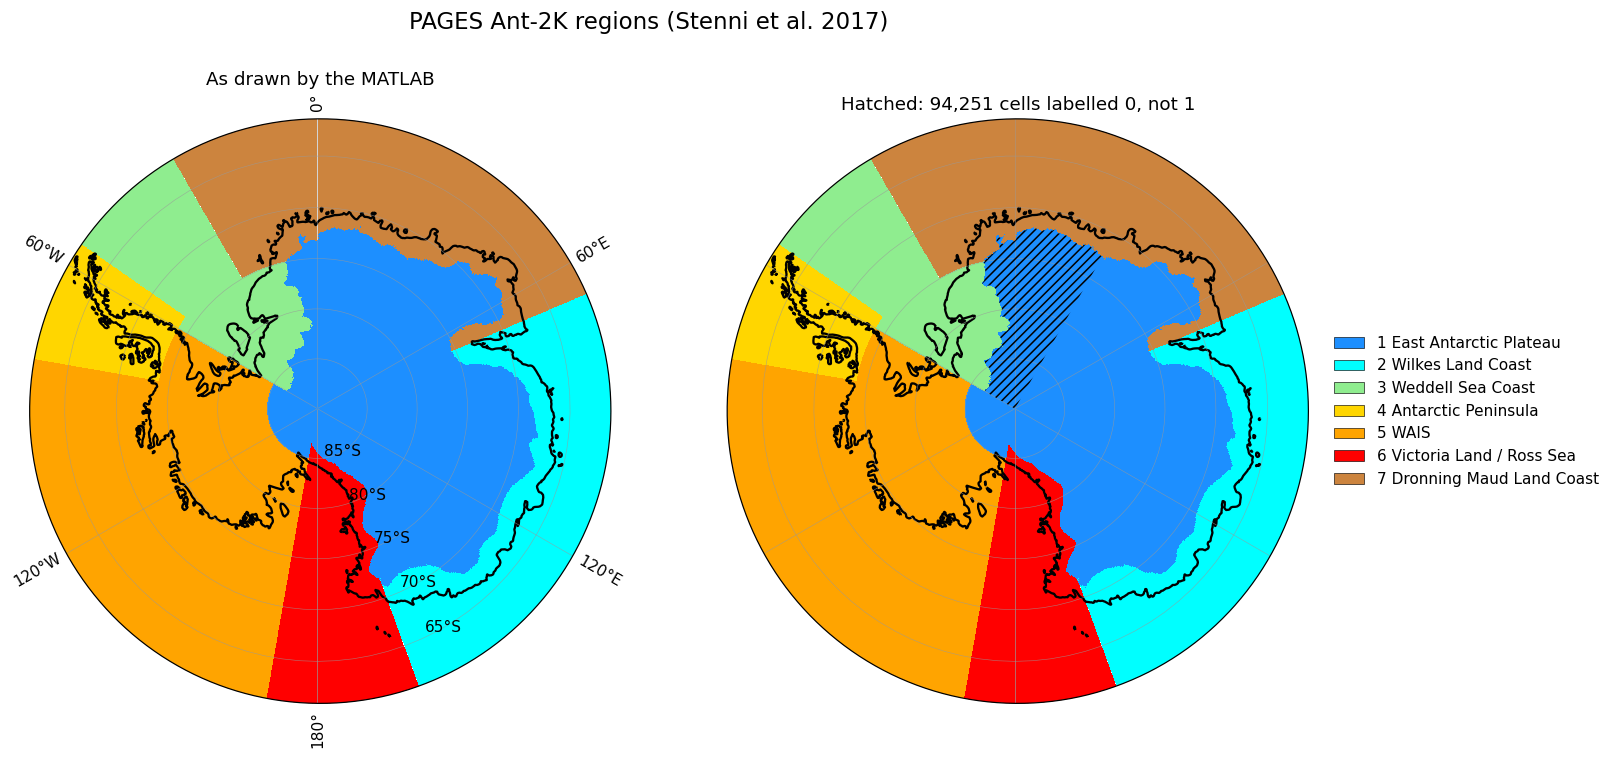

region-0 land cells: 94,251 = 22% of the plateau
  1 East Antarctic Plateau      53.2%
  2 Wilkes Land Coast            8.1%
  3 Weddell Sea Coast            6.3%
  4 Antarctic Peninsula          2.8%
  5 WAIS                        18.1%
  6 Victoria Land / Ross Sea     4.7%
  7 Dronning Maud Land Coast     6.9%


In [9]:
cmap_r, norm_r = region_cmap()

fig = plt.figure(figsize=(15, 7.5))
ax1 = polar_axes(fig, (1,2,1), lat_max=-61.0)
surfm(ax1, lat_g, lon_g, np.where(ri_raw == 0, 1.0, ri_raw), cmap=cmap_r, norm=norm_r)
add_coast(ax1); ax1.set_title('As drawn by the MATLAB')

ax2 = polar_axes(fig, (1,2,2), lat_max=-61.0, labels=False)
surfm(ax2, lat_g, lon_g, ri_fix, cmap=cmap_r, norm=norm_r)
ax2.contourf(lon_g, lat_g, np.where(ri_raw == 0, 1.0, np.nan), levels=[.5, 1.5],
             colors='none', hatches=['////'], transform=PLATE, zorder=4)
add_coast(ax2)
n0 = int(np.sum((ri_raw == 0) & (Z > 10)))
ax2.set_title(f'Hatched: {n0:,} cells labelled 0, not 1')
region_legend(ax2)
fig.suptitle('PAGES Ant-2K regions (Stenni et al. 2017)', fontsize=15)
plt.show()

print(f'region-0 land cells: {n0:,} = {n0/np.sum((ri_fix==1)&(Z>10)):.0%} of the plateau')
w = np.cos(np.deg2rad(LA)) * (Z > 10)
tot = np.nansum(np.where(np.isfinite(ri_fix), w, 0.))
for v in range(1, 8):
    print(f'  {v} {REGION_NAMES[v]:26s} {np.nansum(np.where(ri_fix==v, w, 0.))/tot:6.1%}')


In [10]:
sites = {'Dome C':(-75.10,123.35), 'Vostok':(-78.47,106.84), 'South Pole':(-89.99,0.0),
         'EDML/Kohnen':(-75.00,0.07), 'Talos Dome':(-72.78,159.07),
         'Byrd':(-80.01,-119.32), 'Law Dome':(-66.77,112.81),
         'James Ross Is':(-64.20,-57.68), 'Berkner Is':(-79.55,-45.68),
         'Taylor Dome':(-77.78,158.72), 'Neumayer':(-70.65,-8.25),
         "Dumont d'Urville":(-66.66,140.00)}

rows = []
for n, (la, lo) in sites.items():
    la_, lo_ = np.atleast_1d(la), np.atleast_1d(lo)
    z_ = elev(la_, lo_)
    rows.append({'site': n,
                 'matlab':    regions_ant2k(la_, lo_, z_, True)[0],
                 'corrected': regions_ant2k(la_, lo_, z_, False)[0],
                 'region': REGION_NAMES.get(regions_ant2k(la_, lo_, z_, False)[0], '?')})
pd.DataFrame(rows).set_index('site')


,matlab,corrected,region
site,,,
Dome C,1.0,1.0,East Antarctic Plateau
Vostok,1.0,1.0,East Antarctic Plateau
South Pole,0.0,1.0,East Antarctic Plateau
EDML/Kohnen,0.0,1.0,East Antarctic Plateau
Talos Dome,1.0,1.0,East Antarctic Plateau
Byrd,5.0,5.0,WAIS
Law Dome,2.0,2.0,Wilkes Land Coast
James Ross Is,4.0,4.0,Antarctic Peninsula
Berkner Is,3.0,3.0,Weddell Sea Coast


In [11]:
def load_era5(path=ERA5_T2M):
    """Monthly ERA5 as (time, lat, lon) in degC, lon 0-360 ascending."""
    ds = xr.open_dataset(path)
    da = ds['t2m'] if 't2m' in ds else ds['t']
    note = ('ERA5 2 m temperature (t2m, paramId 167)' if 't2m' in ds
            else 'ERA5 1000 hPa temperature (t, paramId 130) -- NOT 2 m')
    if 'pressure_level' in da.dims:
        da = da.squeeze('pressure_level', drop=True)
    rn = {k: v for k, v in {'valid_time':'time','latitude':'lat','longitude':'lon'}.items()
          if k in da.dims or k in da.coords}
    da = (da.rename(rn).assign_coords(lon=lambda d: np.mod(d.lon, 360.))
            .sortby('lon').sortby('lat') - 273.15)
    da.attrs['note'] = note
    return da

def load_ice_cores(path=ICECORES):
    """Drops record 8: zero-length Age with List_lat exactly 0.0 (a placeholder)."""
    m = sio.loadmat(path)
    age = [np.asarray(a, float).ravel() for a in m['Age'][0]]
    d18 = [np.asarray(a, float).ravel() for a in m['d18O'][0]]
    la = np.asarray(m['List_lat'][0], float); lo = np.asarray(m['List_lon'][0], float)
    keep = [i for i, (a, d, x) in enumerate(zip(age, d18, la))
            if a.size > 0 and d.size == a.size and np.isfinite(x) and x != 0.]
    return [age[i] for i in keep], [d18[i] for i in keep], la[keep], lo[keep]

def load_aws(path=AWSMAT):
    s = sio.loadmat(path, squeeze_me=True, struct_as_record=False)['dataAWS']
    return [dict(name=n, year=np.asarray(getattr(s,n).year, float).ravel(),
                 temp=np.asarray(getattr(s,n).T_AWS, float).ravel(),
                 lat=float(getattr(s,n).lat), lon=float(getattr(s,n).lon))
            for n in s._fieldnames]

era5 = load_era5(); print(era5.attrs['note'])
core_age, core_d18, core_lat, core_lon = load_ice_cores()
stations = load_aws()
print(f'{len(core_age)} usable cores, {len(stations)} stations')

# sanity check against true annual means
m = era5.mean('time')
check = {"Dumont d'Urville":(-66.7,140.0,-11), 'Halley':(-75.35,333.6,-18),
         'South Pole':(-90,0,-49), 'Vostok':(-78.5,106.9,-55), 'Dome C':(-75.1,123.35,-54)}
pd.DataFrame([{'site':k, 'file_degC':round(float(m.sel(lat=la,lon=lo,method='nearest')),1),
               'true':tru,
               'error':round(float(m.sel(lat=la,lon=lo,method='nearest'))-tru,1)}
              for k,(la,lo,tru) in check.items()]).set_index('site')


ERA5 2 m temperature (t2m, paramId 167)
78 usable cores, 17 stations


,file_degC,true,error
site,,,
Dumont d'Urville,NaN,-11,NaN
Halley,NaN,-18,NaN
South Pole,-45.2,-49,3.8
Vostok,-51.3,-55,3.7
Dome C,-50.0,-54,4.0


(47, 301, 3600) 1979-2025, NaN fraction 0.383


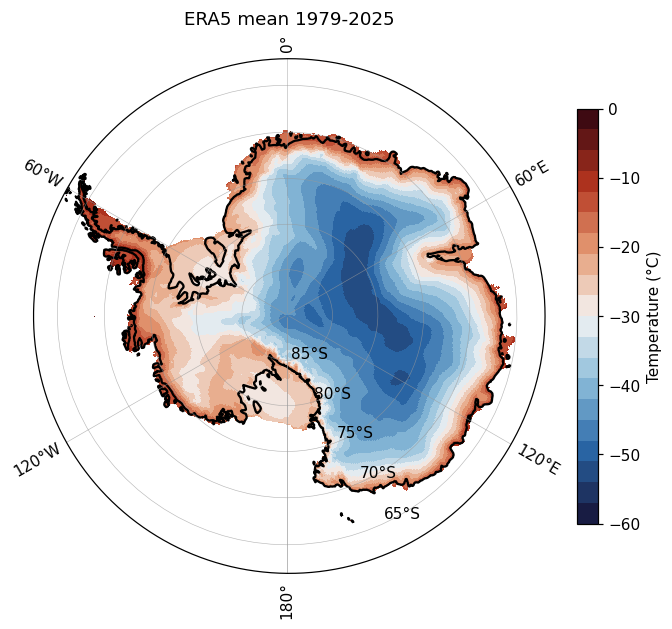

In [12]:
ann   = era5.groupby('time.year').mean('time')
years = ann.year.values.astype(float)
lat_e, lon_e = ann.lat.values, ann.lon.values
cube  = ann.values.astype('float32')
print(cube.shape, f'{years[0]:.0f}-{years[-1]:.0f}, NaN fraction {np.isnan(cube).mean():.3f}')

fig = plt.figure(figsize=(7.5, 7))
ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = surfm(ax, lat_e, lon_e, np.nanmean(cube, 0),
             cmap=cmocean_like('balance', 20), vmin=-60, vmax=0)
add_coast(ax); fig.colorbar(mesh, ax=ax, shrink=.7, label='Temperature (°C)')
ax.set_title(f'ERA5 mean {years[0]:.0f}-{years[-1]:.0f}')
plt.show()


In [13]:
def trend_1d(x, y, y0=None, y1=None):
    """Slope, p-value, n. Half-open window [y0, y1), NaNs dropped pairwise --
    matching the MATLAB's polyfit + corrcoef pattern."""
    x = np.asarray(x, float).ravel(); y = np.asarray(y, float).ravel()
    n = min(x.size, y.size); x, y = x[:n], y[:n]
    if y0 is not None:
        s = (x >= y0) & (x < y1); x, y = x[s], y[s]
    ok = np.isfinite(x) & np.isfinite(y); x, y = x[ok], y[ok]
    if x.size < 3 or np.ptp(x) == 0:
        return np.nan, np.nan, x.size
    r = stats.linregress(x, y)
    return r.slope, r.pvalue, x.size

def trend_map(yrs, cb, y0, y1, min_years=10):
    """Vectorised per-gridpoint trend. Returns (slope, pvalue) in units/year."""
    yrs = np.asarray(yrs, float); cb = np.asarray(cb, float)
    s = (yrs >= y0) & (yrs < y1); x = yrs[s]; Y = cb[s]; sh = Y.shape[1:]
    Y2 = Y.reshape(len(x), -1); good = np.isfinite(Y2); n = good.sum(0)
    Yf = np.where(good, Y2, 0.)
    Xf = np.where(good, np.repeat(x[:, None], Y2.shape[1], 1), 0.)
    with np.errstate(invalid='ignore', divide='ignore'):
        sx, sy = Xf.sum(0), Yf.sum(0)
        sxx, sxy, syy = (Xf*Xf).sum(0), (Xf*Yf).sum(0), (Yf*Yf).sum(0)
        den = n*sxx - sx*sx
        slope = (n*sxy - sx*sy) / den
        r = np.clip((n*sxy - sx*sy) / np.sqrt(den*(n*syy - sy*sy)), -1, 1)
        t = r * np.sqrt((n-2) / np.maximum(1e-12, 1 - r*r))
        p = 2 * stats.t.sf(np.abs(t), np.maximum(n-2, 1))
    bad = (n < min_years) | ~np.isfinite(den) | (den == 0)
    return np.where(bad, np.nan, slope).reshape(sh), np.where(bad, np.nan, p).reshape(sh)

rows = []
for s in stations:
    sl, p, n = trend_1d(s['year'], s['temp'], YEAR_START, YEAR_STOP)
    rows.append(dict(station=s['name'], lat=s['lat'], lon=s['lon'],
                     trend_C_per_dec=round(10*sl, 3), p=round(p, 3), n=n))
aws = pd.DataFrame(rows).set_index('station')
aws['sig'] = aws.p < 0.05
aws.sort_values('trend_C_per_dec', ascending=False)


,lat,lon,trend_C_per_dec,p,n,sig
station,,,,,,
FaradayVernadsky,-65.14,-64.15,0.339,0.020,40,True
Rothera,-67.34,-68.08,0.318,0.063,40,False
AmundsenScott,-90.00,0.00,0.312,0.012,40,True
McMurdo,-77.90,166.70,0.256,0.053,40,False
Marambio,-64.24,-56.63,0.230,0.186,40,False
Vostok,-78.50,106.90,0.189,0.180,37,False
Bellingshausen,-62.12,-58.58,0.117,0.283,40,False
Mawson,-67.60,62.90,0.104,0.320,40,False
Davis,-68.60,78.00,0.061,0.642,40,False


mean |trend difference| from the /365 axis bug: 0.0266 °C/dec


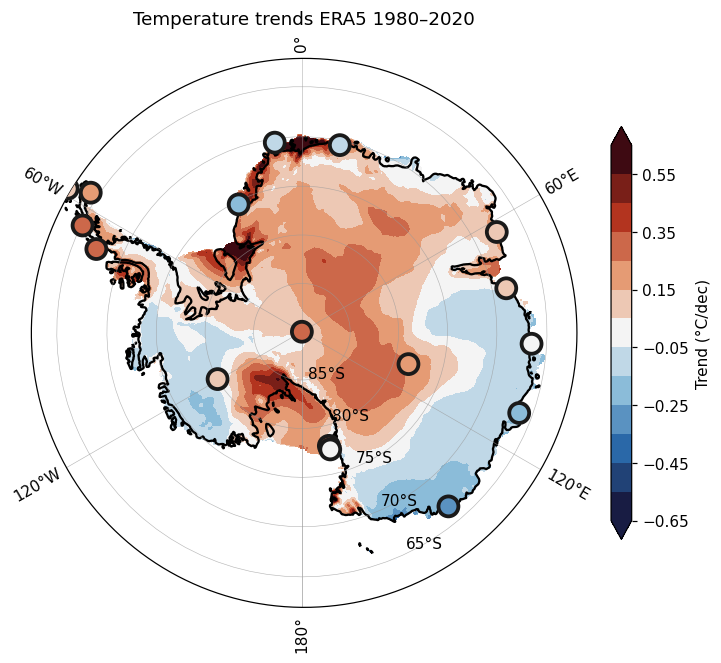

grid trend range -0.49 to 0.96 °C/dec


In [14]:
slope_e, pval_e = trend_map(years, cube, YEAR_START, YEAR_STOP)

# what the MATLAB's datenum/365 axis bug cost (line 74 uses /365, line 429 /365.25)
slope_bug, _ = trend_map(years + 1.5, cube, YEAR_START, YEAR_STOP)
print(f'mean |trend difference| from the /365 axis bug: '
      f'{np.nanmean(np.abs(10*(slope_e - slope_bug))):.4f} °C/dec')

fig = plt.figure(figsize=(8, 7.5))
ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.contourf(lon_e, lat_e, 10*slope_e, levels=LEV, cmap=cmap_t,
                   extend='both', transform=PLATE)
scatterm(ax, aws.lat, aws.lon, s=170, c=aws.trend_C_per_dec, cmap=cmap_t,
         vmin=-TREND_LIM, vmax=TREND_LIM, edgecolors='0.1', linewidths=2.5)
add_coast(ax)
fig.colorbar(mesh, ax=ax, shrink=.65, label='Trend (°C/dec)', ticks=LEV[::2])
ax.set_title(f'Temperature trends ERA5 {YEAR_START}–{YEAR_STOP}')
plt.show()

print('grid trend range %.2f to %.2f °C/dec' % (10*np.nanmin(slope_e), 10*np.nanmax(slope_e)))


In [15]:
s2 = np.array([trend_1d(a, d*2.0, CORE_START, CORE_STOP)[:2]
               for a, d in zip(core_age, core_d18)])
slope_c, pval_c = s2[:, 0], s2[:, 1]
sig_c = np.isfinite(pval_c) & (pval_c < 0.05)

end = np.array([a.max() for a in core_age])
print(f'records end between {end.min():.0f} and {end.max():.0f} — '
      f'so "{CORE_START}–{CORE_STOP}" is really to {end.max():.0f} at best')
print(f'{sig_c.sum()}/{len(core_age)} cores significant at p<0.05')


records end between 1467 and 2012 — so "1950–2020" is really to 2012 at best
21/78 cores significant at p<0.05


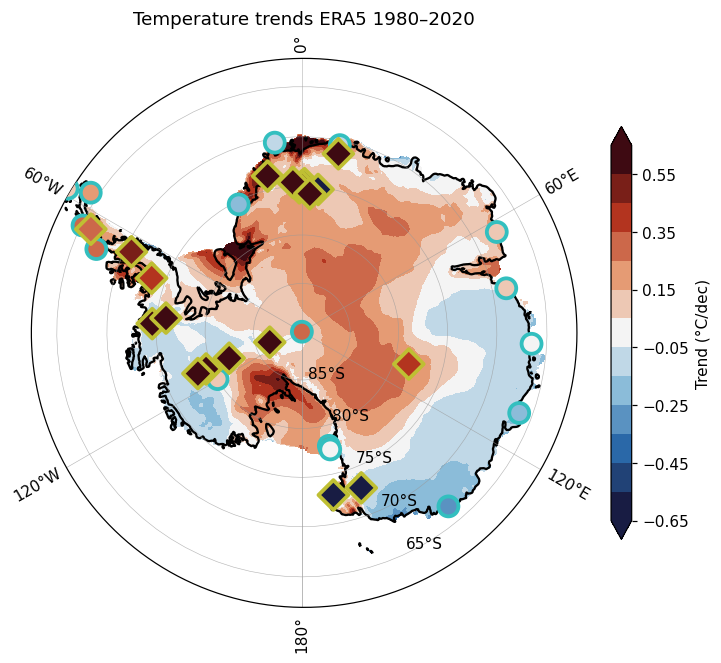

In [16]:
fig = plt.figure(figsize=(8, 7.5))
ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.contourf(lon_e, lat_e, 10*slope_e, levels=LEV, cmap=cmap_t,
                   extend='both', transform=PLATE)
add_coast(ax)
# stations: cyan edge (MATLAB line 422)
scatterm(ax, aws.lat, aws.lon, s=170, c=aws.trend_C_per_dec, cmap=cmap_t,
         vmin=-TREND_LIM, vmax=TREND_LIM, edgecolors=[(0.2,0.75,0.75)], linewidths=2.5)
# ice cores: yellow-edged diamonds (MATLAB line 145)
scatterm(ax, core_lat[sig_c], core_lon[sig_c], s=190, marker='D',
         c=10*slope_c[sig_c], cmap=cmap_t, vmin=-TREND_LIM, vmax=TREND_LIM,
         edgecolors=[(0.75,0.75,0.2)], linewidths=2.5)
fig.colorbar(mesh, ax=ax, shrink=.65, label='Trend (°C/dec)', ticks=LEV[::2])
ax.set_title(f'Temperature trends ERA5 {YEAR_START}–{YEAR_STOP}')
plt.show()


78 cores → 33 groups (largest 18, 15 merged); 15 p<0.05


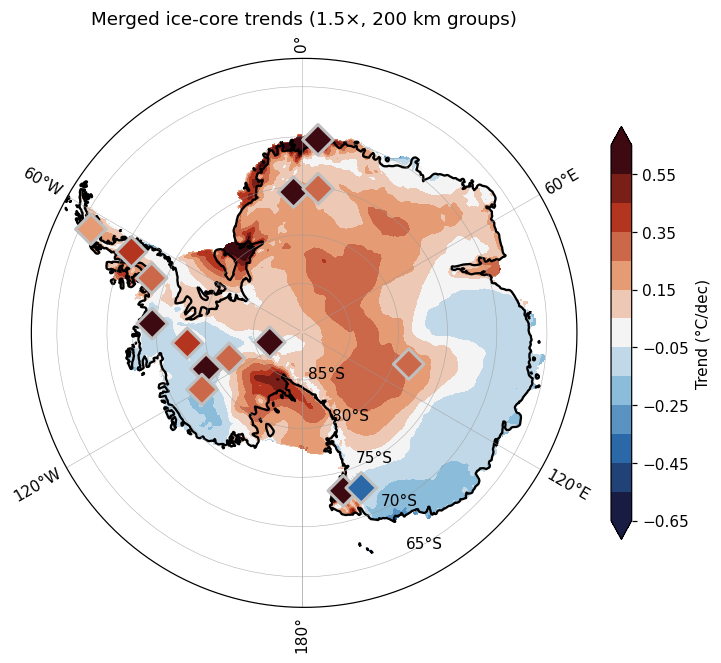

In [17]:
def haversine_km(la1, lo1, la2, lo2, R=6371.0088):
    """MATLAB uses distance(...,wgs84Ellipsoid('km')); the spherical
    approximation differs by <0.5%, far below the 200 km threshold."""
    la1, lo1, la2, lo2 = map(np.radians, (la1, lo1, la2, lo2))
    a = np.sin((la2-la1)/2)**2 + np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return 2*R*np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def merge_neighbours(age, vals, lat, lon, threshold_km=200.):
    """Greedy spatial merge. Order-dependent by construction, and the group
    takes its SEED record's coordinates -- faithful to the MATLAB."""
    n = len(age); assigned = np.zeros(n, bool)
    out = {'age':[], 'value':[], 'lat':[], 'lon':[], 'members':[]}
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    for i in range(n):
        if assigned[i]: continue
        d = haversine_km(lat[i], lon[i], lat, lon)
        mem = np.flatnonzero((d <= threshold_km) & ~assigned)
        common = np.unique(np.concatenate([np.asarray(age[j]).ravel() for j in mem]))
        st = np.full((common.size, mem.size), np.nan)
        for k, j in enumerate(mem):
            a = np.asarray(age[j], float).ravel(); v = np.asarray(vals[j], float).ravel()
            if a.size == 0 or a.size != v.size: continue
            o = np.argsort(a)
            st[:, k] = np.interp(common, a[o], v[o], left=np.nan, right=np.nan)
        with np.errstate(invalid='ignore'):
            out['value'].append(np.nanmean(st, 1))
        out['age'].append(common); out['lat'].append(lat[i]); out['lon'].append(lon[i])
        out['members'].append(mem); assigned[mem] = True
    out['lat'] = np.array(out['lat']); out['lon'] = np.array(out['lon'])
    return out

g = merge_neighbours(core_age, core_d18, core_lat, core_lon, 200.)
sm = np.array([trend_1d(a, np.asarray(v)*1.5, CORE_START, CORE_STOP)[:2]
               for a, v in zip(g['age'], g['value'])])
slope_m, pval_m = sm[:, 0], sm[:, 1]
sig_m = np.isfinite(pval_m) & (pval_m < 0.05)
sizes = [len(mm) for mm in g['members']]
print(f"{len(core_age)} cores → {len(g['age'])} groups "
      f"(largest {max(sizes)}, {sum(1 for s in sizes if s>1)} merged); {sig_m.sum()} p<0.05")

fig = plt.figure(figsize=(8, 7.5))
ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.contourf(lon_e, lat_e, 10*slope_e, levels=LEV, cmap=cmap_t,
                   extend='both', transform=PLATE)
scatterm(ax, g['lat'][sig_m], g['lon'][sig_m], s=200, c=10*slope_m[sig_m], marker='D',
         cmap=cmap_t, vmin=-TREND_LIM, vmax=TREND_LIM, edgecolors='0.75', linewidths=2)
add_coast(ax)
fig.colorbar(mesh, ax=ax, shrink=.65, label='Trend (°C/dec)', ticks=LEV[::2])
ax.set_title('Merged ice-core trends (1.5×, 200 km groups)')
plt.show()


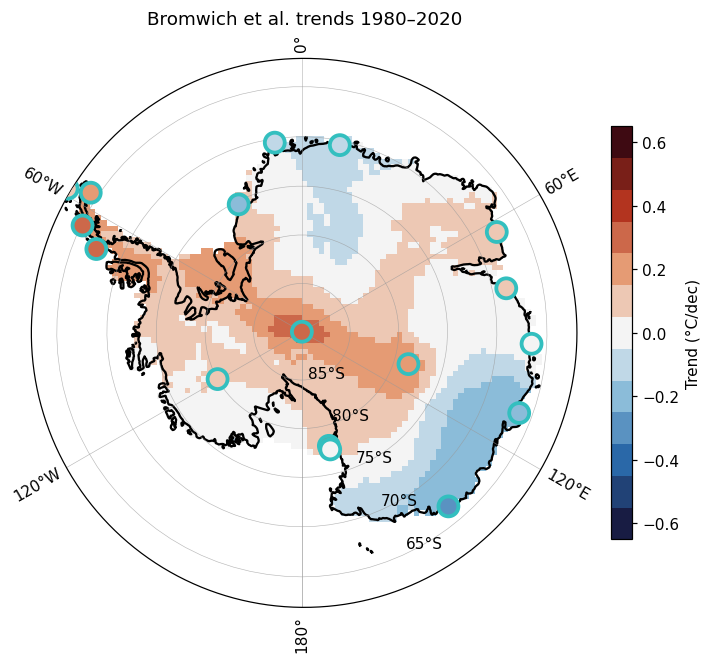

In [18]:
dsb  = xr.open_dataset(BROMWICH)
annb = dsb['RECON'].groupby('time.year').mean('time')
slope_b, pval_b = trend_map(annb.year.values.astype(float),
                            annb.values.astype('float32'), YEAR_START, YEAR_STOP)
land_b = dsb['LANDMASK'].values > 0.5

fig = plt.figure(figsize=(8, 7.5))
ax = polar_axes(fig, 111, lat_max=-62.0)
# grid is curvilinear: lat/lon are 2-D (114x114 WRF polar-stereo)
mesh = ax.pcolormesh(dsb['lon'].values, dsb['lat'].values,
                     10*np.where(land_b, slope_b, np.nan), cmap=cmap_t,
                     vmin=-TREND_LIM, vmax=TREND_LIM, transform=PLATE, shading='auto')
scatterm(ax, aws.lat, aws.lon, s=170, c=aws.trend_C_per_dec, cmap=cmap_t,
         vmin=-TREND_LIM, vmax=TREND_LIM, edgecolors=[(0.2,0.75,0.75)], linewidths=2.5)
add_coast(ax); fig.colorbar(mesh, ax=ax, shrink=.65, label='Trend (°C/dec)')
ax.set_title(f'Bromwich et al. trends {YEAR_START}–{YEAR_STOP}')
plt.show()


PC1 27.4%  PC2 21.2%  PC3 11.6%
  12 PCs reach 90%
  18 PCs reach 95%   <- MATLAB line 502 guesses "20 roughly means 95%"
  33 PCs reach 99%


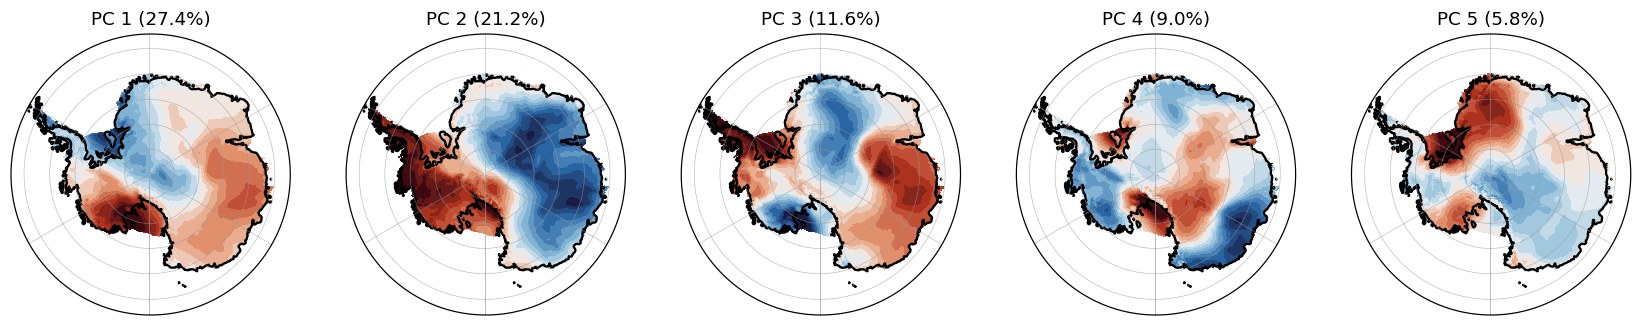

In [19]:
def pca_fields(cb, n_components=None):
    """MATLAB orientation: pca(data2D) with data2D (n_cells x n_years) treats
    GRID CELLS as observations and YEARS as variables -- transpose of the usual
    EOF convention. So score reshapes into spatial maps and coeff is temporal."""
    cb = np.asarray(cb, float); nt = cb.shape[0]; sp = cb.shape[1:]
    anom = cb - np.nanmean(cb, 0, keepdims=True)
    d2 = anom.reshape(nt, -1).T
    fin = np.all(np.isfinite(d2), 1); X = d2[fin]
    nc = n_components or min(X.shape)
    p = PCA(n_components=nc); sc = p.fit_transform(X)
    full = np.full((d2.shape[0], nc), np.nan); full[fin] = sc
    return dict(score=full.T.reshape((nc,)+sp), coeff=p.components_.T,
                explained=p.explained_variance_ratio_*100,
                cumulative=np.cumsum(p.explained_variance_ratio_)*100)

res = pca_fields(cube, n_components=min(80, cube.shape[0]))
exp, cum = res['explained'], res['cumulative']
print(f'PC1 {exp[0]:.1f}%  PC2 {exp[1]:.1f}%  PC3 {exp[2]:.1f}%')
for t in (90, 95, 99):
    note = '   <- MATLAB line 502 guesses "20 roughly means 95%"' if t == 95 else ''
    print(f'  {int(np.searchsorted(cum, t)+1)} PCs reach {t}%{note}')

fig = plt.figure(figsize=(19, 4.4))
for i in range(5):
    ax = polar_axes(fig, (1,5,i+1), lat_max=-62.0, labels=False)
    v = res['score'][i]; lim_v = np.nanpercentile(np.abs(v), 99)
    surfm(ax, lat_e, lon_e, v, cmap=cmocean_like('balance', 20), vmin=-lim_v, vmax=lim_v)
    add_coast(ax); ax.set_title(f'PC {i+1} ({exp[i]:.1f}%)')
plt.show()


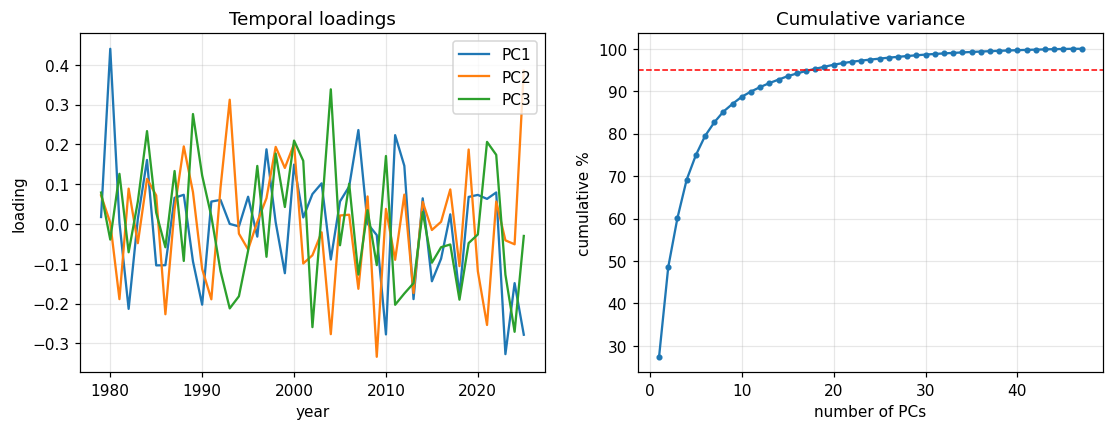

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for i in range(3):
    axs[0].plot(years, res['coeff'][:, i], label=f'PC{i+1}')
axs[0].set_xlabel('year'); axs[0].set_ylabel('loading')
axs[0].set_title('Temporal loadings'); axs[0].legend(); axs[0].grid(alpha=.3)
axs[1].plot(np.arange(1, len(cum)+1), cum, 'o-', ms=3)
axs[1].axhline(95, color='r', ls='--', lw=1)
axs[1].set_xlabel('number of PCs'); axs[1].set_ylabel('cumulative %')
axs[1].set_title('Cumulative variance'); axs[1].grid(alpha=.3)
plt.show()


In [23]:
# MATLAB: yt = T2my(j,i,xd>=1950 & xd<=2021); corrcoef(Stat_data(k,:),yt) for k=1:23;
#         pc_correl = max(Correl_map,[],3);  surfm(...,pc_correl'.^2)
WIN_START, WIN_STOP = 1950, 2021
MATLAB_NAN = True      # MATLAB corrcoef -> NaN on any NaN; max() then omits it

sel = (years >= WIN_START) & (years <= WIN_STOP)
yrs = years[sel]

stat = np.full((len(stations), len(yrs)), np.nan)
for i, s in enumerate(stations):
    for y, t in zip(s['year'], s['temp']):
        j = np.flatnonzero(yrs == y)
        if j.size: stat[i, j[0]] = t

coeff = res['coeff'][sel]
corr = np.full((coeff.shape[1], stat.shape[0]), np.nan)
for i in range(coeff.shape[1]):
    for j in range(stat.shape[0]):
        ok = np.isfinite(stat[j]) & np.isfinite(coeff[:, i])
        if ok.sum() > 5:
            corr[i, j] = np.corrcoef(stat[j][ok], coeff[ok, i])[0, 1]
pcid = np.nanmax(np.abs(corr), 1) > 0.5
print('PCs correlating |r|>0.5 with a station:', (np.flatnonzero(pcid)+1).tolist())

anom = cube[sel] - np.nanmean(cube[sel], 0, keepdims=True)
T = anom.reshape(len(yrs), -1)
best, used = np.full(T.shape[1], -np.inf), 0
for j in range(stat.shape[0]):
    ok = np.isfinite(stat[j])
    if MATLAB_NAN:
        if not ok.all():        # any gap -> corrcoef is NaN -> max() drops it
            continue
    elif ok.sum() < 10:
        continue
    used += 1
    sv = stat[j][ok] - stat[j][ok].mean()
    Tv = T[ok] - T[ok].mean(0, keepdims=True)
    with np.errstate(invalid='ignore', divide='ignore'):
        r = (sv @ Tv) / np.sqrt((sv @ sv) * (Tv*Tv).sum(0))
    best = np.fmax(best, np.where(np.isfinite(r), r, -np.inf))   # signed max, as MATLAB
r2 = np.where(np.isfinite(best), best**2, np.nan).reshape(cube.shape[1:])

print(f'window {yrs[0]:.0f}-{yrs[-1]:.0f} = {len(yrs)} years; {used}/{len(stations)} stations used')
if len(yrs) < 72:
    print(f'  WARNING: the MATLAB used 72 years (1950-2021). With only {len(yrs)}, '
          f'max-correlation r² is inflated — expect ~0.5 here against ~0.37 at 72 years.')
print(f'median r² (all cells) = {np.nanmedian(r2):.2f}')


PCs correlating |r|>0.5 with a station: [1, 2, 3, 4]
window 1979-2021 = 43 years; 13/17 stations used
median r² (all cells) = 0.49


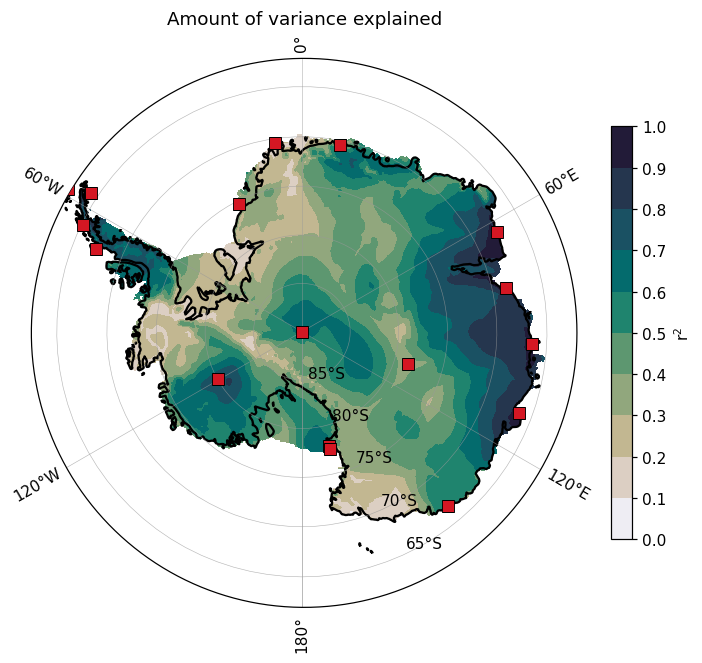

median r² over land = 0.49 (range 0.06–0.97)


In [28]:
LA_e, LO_e = np.meshgrid(lat_e, lon_e, indexing='ij')
land = elev.land_mask(LA_e, LO_e)      # BedMachine mask, not an elevation cut

fig = plt.figure(figsize=(8, 7.5))
ax = polar_axes(fig, 111, lat_max=-62.0)
mesh = ax.contourf(lon_e, lat_e, np.where(land, r2, np.nan),
                   levels=np.arange(0, 1.01, 0.1),
                   cmap=cmocean_like('rain', 10), transform=PLATE)
add_coast(ax)
scatterm(ax, [s['lat'] for s in stations], [s['lon'] for s in stations],
         s=55, marker='s', c=[(212/255, 23/255, 35/255)],
         edgecolors='k', linewidths=.6)

fig.colorbar(mesh, ax=ax, shrink=.65, label='r$^2$', ticks=np.arange(0, 1.01, .1))
ax.set_title('Amount of variance explained')
plt.show()

r2l = np.where(land, r2, np.nan)
print(f'median r² over land = {np.nanmedian(r2l):.2f} '
      f'(range {np.nanmin(r2l):.2f}–{np.nanmax(r2l):.2f})')
